In [5]:
import csv, pandas, platform, os, seaborn, torch
import lightning as L
import torch.utils.data as D
import torchmetrics as M

data_path = "BostonHousing.csv"
torch.manual_seed(0)

print("Versions: python", platform.python_version(), "| torch", torch.__version__, "| lightning", L.__version__)

Versions: python 3.12.11 | torch 2.10.0+cpu | lightning 2.6.1


In [8]:
class TabularDataset(D.TensorDataset):
    """TabularDataSet loads data from a pandas DataFrame assuming the last column is the target and all other columns are features that can be converted to float."""
    def __init__(self, dataframe: pandas.DataFrame):
        rows = dataframe.values.astype(float)
        data = torch.tensor(rows, dtype=torch.float32)
        super().__init__(data[:, :-1], data[:, -1])
    
    def num_features(self) -> int:
        return self[0][0].size()[0]

df = pandas.read_csv(data_path)
dataset = TabularDataset(df)
print("Created a TabularDataset with", dataset.num_features(), "features.")

Created a TabularDataset with 13 features.


In [9]:
df.sample(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
235,0.33045,0.0,6.20,0,0.507,6.086,61.5,3.6519,8,307,17.4,376.75,10.88,24.0
179,0.05780,0.0,2.46,0,0.488,6.980,58.4,2.8290,3,193,17.8,396.90,5.04,37.2
378,23.64820,0.0,18.10,0,0.671,6.380,96.2,1.3861,24,666,20.2,396.90,23.69,13.1
411,14.05070,0.0,18.10,0,0.597,6.657,100.0,1.5275,24,666,20.2,35.05,21.22,17.2
108,0.12802,0.0,8.56,0,0.520,6.474,97.1,2.4329,5,384,20.9,395.24,12.27,19.8


In [10]:
train, val, test = D.random_split(dataset, [.6, .3, .1])
datamodule = L.LightningDataModule.from_datasets(train, val, test, batch_size=32, num_workers=0)
print("Created a DataModule with:", len(datamodule.train_dataloader().dataset), "training items,", len(datamodule.val_dataloader().dataset), "validation items and", len(datamodule.test_dataloader().dataset), "test items.")

Created a DataModule with: 304 training items, 152 validation items and 50 test items.


In [11]:
from torch import nn

class RegressionModel(L.LightningModule):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.criterion = nn.MSELoss()
        self.r2 = M.R2Score()

    def forward(self, x):
        return self.model(x).view(-1)

    def training_step(self, batch):
        x, truth = batch
        out = self(x)
        return self.criterion(out, truth)
    
    def validation_step(self, batch):
        x, truth = batch
        out = self(x)
        loss = self.criterion(out, truth)
        self.log("val_loss", loss)

    def test_step(self, batch):
        x, y = batch
        out = self(x)
        self.log("test_r2", self.r2(out, y), on_step=False, on_epoch=True)

    def predict_step(self, batch):
        x, y = batch
        return self(x)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

model = RegressionModel(num_features=dataset.num_features())

In [12]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

logger = CSVLogger(save_dir=".")
stop = EarlyStopping(monitor="val_loss", mode="min")
trainer = L.Trainer(logger=logger, max_epochs=-1, callbacks=[stop], log_every_n_steps=10)
trainer.fit(model, datamodule=datamodule)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type       | Params | Mode  | FLOPs
---------------------------------------------------------
0 | model     | Sequential | 961    | train | 0    
1 | criterion | MSELoss    | 0      | train | 0    
2 | r2        | R2Score    | 0      | train | 0    
---------------------------------------------------------
961       Trainable params
0         Non-trainable params
961       Total params
0.004     Total estimated model params size (MB)
6         Modules in train mode
0  

Sanity Checking: |                                                                                            …

C:\Users\alexm\Desktop\6\fontys-university\S3\playground\linier-regression\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\alexm\Desktop\6\fontys-university\S3\playground\linier-regression\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\alexm\Desktop\6\fontys-university\S3\playground\linier-regression\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\alexm\Desktop\6\fontys-university\S3\playground\linier-regression\.venv\Lib\site-packages\l

Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

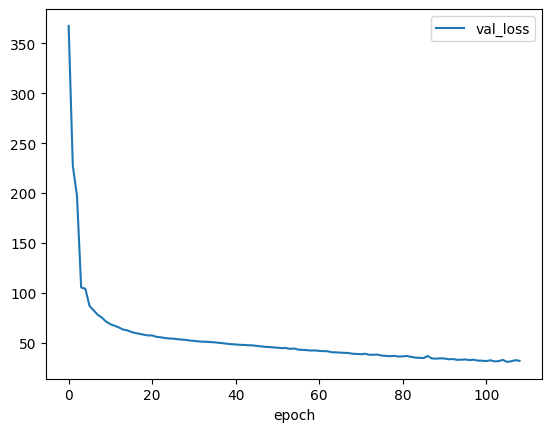

In [13]:
metrics = pandas.read_csv(os.path.join(trainer.log_dir, "metrics.csv"))
plot = metrics[["epoch", "val_loss"]].set_index("epoch").plot()

In [14]:
score = trainer.test(model, datamodule=datamodule)

C:\Users\alexm\Desktop\6\fontys-university\S3\playground\linier-regression\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\alexm\Desktop\6\fontys-university\S3\playground\linier-regression\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\alexm\Desktop\6\fontys-university\S3\playground\linier-regression\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Testing: |                                                                                                    …

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_r2            0.6255152225494385
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


C:\Users\alexm\Desktop\6\fontys-university\S3\playground\linier-regression\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Predicting: |                                                                                                 …

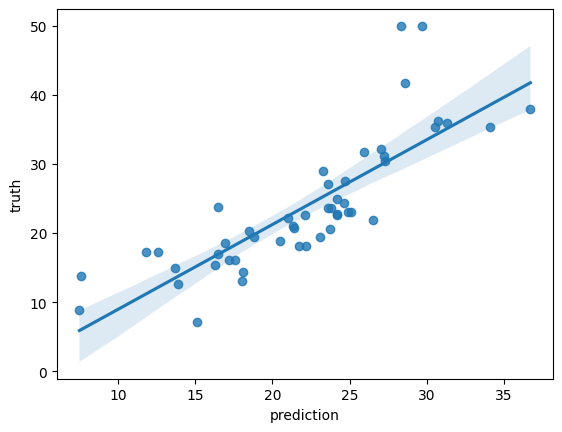

In [15]:
dataloader = datamodule.test_dataloader()
output = trainer.predict(model, dataloaders=dataloader)
predictions = torch.cat(output)
results = [[round(truth[1].item(),1), round(prediction.item(),1)] for truth, prediction in zip(dataloader.dataset, predictions)]
df = pandas.DataFrame(results, columns=["truth", "prediction"])
plot = seaborn.regplot(data=df, y="truth", x="prediction")

In [16]:
df["error"] = abs(df["truth"] - df["prediction"])
df

,truth,prediction,error
0,18.5,16.9,1.6
1,27.1,23.6,3.5
2,22.6,22.1,0.5
3,14.3,18.1,3.8
4,25.0,24.2,0.8
5,17.2,11.8,5.4
6,21.0,21.3,0.3
7,18.2,22.2,4.0
8,23.1,25.1,2.0
9,16.1,17.6,1.5
